# <center>CSE 4/546: Reinforcement Learning</center>
## <center>Prof. Alina Vereshchaka</center>
### <center>Assignment 1, Part 3</center>

In [2]:
# Imports
import gymnasium
from gymnasium import spaces
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import copy
import pickle

### Stock Trading Environment 

In [4]:
# Defining the Stock Trading Environment.
"""DON'T MAKE ANY CHANGES TO THE ENVIRONMENT."""


class StockTradingEnvironment(gymnasium.Env):
    """This class implements the Stock Trading environment."""

    def __init__(self, file_path, train=True, number_of_days_to_consider=10):
        """This method initializes the environment.

        :param file_path: - Path of the CSV file containing the historical stock data.
        :param train: - Boolean indicating whether the goal is to train or test the performance of the agent.
        :param number_of_days_to_consider = Integer representing the number of days the for which the agent
                considers the trend in stock price to make a decision."""

        self.file_path = file_path
        self.stock_data = pd.read_csv(self.file_path)
        self.train = train

        # Splitting the data into train and test datasets.
        self.training_stock_data = self.stock_data.iloc[:int(0.8 * len(self.stock_data))]
        self.testing_stock_data = self.stock_data.iloc[int(0.8 * len(self.stock_data)):].reset_index()

        self.observation_space = spaces.Discrete(4)
        self.action_space = spaces.Discrete(3)

        self.investment_capital = 100000  # This defines the investment capital that the agent starts with.
        self.number_of_shares = 0  # This defines number of shares currently held by the agent.
        self.stock_value = 0  # This defines the value of the stock currently held by the agent.
        self.book_value = 0  # This defines the total value for which the agent bought the shares.
        # This defines the agent's total account value.
        self.total_account_value = self.investment_capital + self.stock_value
        # List to store the total account value over training or evaluation.
        self.total_account_value_list = []
        # This defines the number of days for which the agent considers the data before taking an action.
        self.number_of_days_to_consider = number_of_days_to_consider
        # The maximum timesteps the agent will take before the episode ends.
        if self.train:
            self.max_timesteps = len(self.training_stock_data) - self.number_of_days_to_consider
        else:
            self.max_timesteps = len(self.testing_stock_data) - self.number_of_days_to_consider
        # Initializing the number of steps taken to 0.
        self.timestep = 0
        self.reset()

    def reset(self):
        """This method resets the environment and returns the observation.

        :returns observation: - Integer in the range of 0 to 3 representing the four possible observations that the
                                agent can receive. The observation depends upon whether the price increased on average
                                in the number of days the agent considers, and whether the agent already has the stock
                                or not.

         info: - A dictionary that can be used to provide additional implementation information."""

        self.investment_capital = 100000  # This defines the investment capital that the agent starts with.
        self.number_of_shares = 0  # This defines number of shares currently held by the agent.
        self.stock_value = 0  # This defines the value of the stock currently held by the agent.
        self.book_value = 0  # This defines the total value for which the agent bought the shares.
        # This defines the agent's total account value.
        self.total_account_value = self.investment_capital + self.stock_value
        # List to store the total account value over training or evaluation.
        self.total_account_value_list = []
        # Initializing the number of steps taken to 0.
        self.timestep = 0

        # Getting the observation vector.
        if self.train:
            # If the task is to train the agent the maximum timesteps will be equal to the number of days considered
            # subtracted from the  length of the training stock data.
            self.max_timesteps = len(self.training_stock_data) - self.number_of_days_to_consider

            # Calculating whether the price increased or decreased/remained the same on the majority of days the agent
            # considers.
            price_increase_list = []
            for i in range(self.number_of_days_to_consider):
                if self.training_stock_data['Close'][self.timestep + 1 + i] \
                        - self.training_stock_data['Close'][self.timestep + i] > 0:
                    price_increase_list.append(1)
                else:
                    price_increase_list.append(0)

            if (np.sum(price_increase_list) / self.number_of_days_to_consider) >= 0.5:
                price_increase = True
            else:
                price_increase = False

            stock_held = False

            # Observation vector that will be passed to the agent.
            observation = [price_increase, stock_held]

        else:
            # If the task is to evaluate the trained agent's performance the maximum timesteps will be equal to the
            # number of days considered subtracted from the  length of the testing stock data.
            self.max_timesteps = len(self.testing_stock_data) - self.number_of_days_to_consider

            # Calculating whether the price increased or decreased/remained the same on the majority of days the agent
            # considers.
            price_increase_list = []
            for i in range(self.number_of_days_to_consider):
                if self.testing_stock_data['Close'][self.timestep + 1 + i] \
                        - self.testing_stock_data['Close'][self.timestep + i] > 0:
                    price_increase_list.append(1)
                else:
                    price_increase_list.append(0)

            if (np.sum(price_increase_list) / self.number_of_days_to_consider) >= 0.5:
                price_increase = True
            else:
                price_increase = False

            stock_held = False

            # Observation vector.
            observation = [price_increase, stock_held]

        if np.array_equal(observation, [True, False]):
            observation = 0
        if np.array_equal(observation, [True, True]):
            observation = 1
        if np.array_equal(observation, [False, False]):
            observation = 2
        if np.array_equal(observation, [False, True]):
            observation = 3

        info = None

        return observation, info

    def step(self, action):
        """This method implements what happens when the agent takes the action to Buy/Sell/Hold.

        :param action: - Integer in the range 0 to 2 inclusive.

        :returns observation: - Integer in the range of 0 to 3 representing the four possible observations that the
                                agent can receive. The observation depends upon whether the price increased on average
                                in the number of days the agent considers, and whether the agent already has the stock
                                or not.
                 reward: - Integer/Float value that's used to measure the performance of the agent.
                 terminated: - Boolean describing whether the episode has terminated.
                 truncated: - Boolean describing whether a truncation condition outside the scope of the MDP is satisfied.
                 info: - A dictionary that can be used to provide additional implementation information."""

        # We give the agent a penalty for taking actions such as buying a stock when the agent doesn't have the
        # investment capital and selling a stock when the agent doesn't have any shares.
        penalty = 0

        if self.train:
            if action == 0:  # Buy
                if self.number_of_shares > 0:
                    penalty = -10
                # Determining the number of shares the agent can buy.
                number_of_shares_to_buy = math.floor(self.investment_capital / self.training_stock_data[
                    'Open'][self.timestep + self.number_of_days_to_consider])
                # Adding to the number of shares the agent has.
                self.number_of_shares += number_of_shares_to_buy

                # Computing the stock value, book value, investment capital and reward.
                if number_of_shares_to_buy > 0:
                    self.stock_value +=\
                        self.training_stock_data['Open'][self.timestep + self.number_of_days_to_consider] \
                        * number_of_shares_to_buy
                    self.book_value += \
                        self.training_stock_data['Open'][self.timestep + self.number_of_days_to_consider]\
                        * number_of_shares_to_buy
                    self.investment_capital -= \
                        self.training_stock_data['Open'][self.timestep + self.number_of_days_to_consider] \
                        * number_of_shares_to_buy

                    reward = 1 + penalty

                else:
                    # Computing the stock value and reward.
                    self.stock_value = \
                        self.training_stock_data['Open'][self.timestep + self.number_of_days_to_consider] \
                        * self.number_of_shares
                    reward = -10

            if action == 1:  # Sell
                # Computing the investment capital, sell value and reward.
                self.investment_capital += \
                    self.training_stock_data['Open'][self.timestep + self.number_of_days_to_consider] \
                    * self.number_of_shares
                sell_value = self.training_stock_data['Open'][self.timestep + self.number_of_days_to_consider] \
                             * self.number_of_shares

                if self.book_value > 0:
                    reward = (sell_value - self.book_value) / self.book_value * 100
                else:
                    reward = -10

                self.number_of_shares = 0
                self.stock_value = 0
                self.book_value = 0

            if action == 2:  # Hold
                # Computing the stock value and reward.
                self.stock_value = self.training_stock_data['Open'][self.timestep + self.number_of_days_to_consider] \
                                   * self.number_of_shares

                if self.book_value > 0:
                    reward = (self.stock_value - self.book_value) / self.book_value * 100
                else:
                    reward = -1

        else:
            if action == 0:  # Buy
                if self.number_of_shares > 0:
                    penalty = -10
                # Determining the number of shares the agent can buy.
                number_of_shares_to_buy = math.floor(self.investment_capital / self.testing_stock_data[
                    'Open'][self.timestep + self.number_of_days_to_consider])
                # Adding to the number of shares the agent has.
                self.number_of_shares += number_of_shares_to_buy

                # Computing the stock value, book value, investment capital and reward.
                if number_of_shares_to_buy > 0:
                    self.stock_value += \
                        self.testing_stock_data['Open'][self.timestep + self.number_of_days_to_consider] \
                        * number_of_shares_to_buy
                    self.book_value += \
                        self.testing_stock_data['Open'][self.timestep + self.number_of_days_to_consider] \
                        * number_of_shares_to_buy
                    self.investment_capital -= \
                        self.testing_stock_data['Open'][self.timestep + self.number_of_days_to_consider] \
                        * number_of_shares_to_buy

                    reward = 1 + penalty

                else:
                    # Computing the stock value and reward.
                    self.stock_value = self.training_stock_data['Open'][
                                           self.timestep + self.number_of_days_to_consider] * self.number_of_shares
                    reward = -10

            if action == 1:  # Sell
                # Computing the investment capital, sell value and reward.
                self.investment_capital += \
                    self.testing_stock_data['Open'][self.timestep + self.number_of_days_to_consider] \
                    * self.number_of_shares
                sell_value = self.training_stock_data['Open'][self.timestep + self.number_of_days_to_consider] \
                             * self.number_of_shares

                if self.book_value > 0:
                    reward = (sell_value - self.book_value) / self.book_value * 100
                else:
                    reward = -10

                self.number_of_shares = 0
                self.stock_value = 0
                self.book_value = 0

            if action == 2:  # Hold
                # Computing the stock value and reward.
                self.stock_value = self.testing_stock_data['Open'][self.timestep + self.number_of_days_to_consider] \
                                   * self.number_of_shares

                if self.book_value > 0:
                    reward = (self.stock_value - self.book_value) / self.book_value * 100
                else:
                    reward = -1

        # Determining if the agent currently has shares of the stock or not.
        if self.number_of_shares > 0:
            stock_held = True
        else:
            stock_held = False

        # Getting the observation vector.
        if self.train:
            # If the task is to train the agent the maximum timesteps will be equal to the number of days considered
            # subtracted from the  length of the training stock data.
            self.max_timesteps = len(self.training_stock_data) - self.number_of_days_to_consider

            # Calculating whether the price increased or decreased/remained the same on the majority of days the agent
            # considers.
            price_increase_list = []
            for i in range(self.number_of_days_to_consider):
                if self.training_stock_data['Close'][self.timestep + 1 + i] \
                        - self.training_stock_data['Close'][self.timestep + i] > 0:
                    price_increase_list.append(1)
                else:
                    price_increase_list.append(0)

            if (np.sum(price_increase_list) / self.number_of_days_to_consider) >= 0.5:
                price_increase = True
            else:
                price_increase = False

            # Observation vector.
            observation = [price_increase, stock_held]

        else:
            # If the task is to evaluate the trained agent's performance the maximum timesteps will be equal to the
            # number of days considered subtracted from the  length of the testing stock data.
            self.max_timesteps = len(self.testing_stock_data) - self.number_of_days_to_consider

            # Calculating whether the price increased or decreased/remained the same on the majority of days the agent
            # considers.
            price_increase_list = []
            for i in range(self.number_of_days_to_consider):
                if self.testing_stock_data['Close'][self.timestep + 1 + i] \
                        - self.testing_stock_data['Close'][self.timestep + i] > 0:
                    price_increase_list.append(1)
                else:
                    price_increase_list.append(0)

            if (np.sum(price_increase_list) / self.number_of_days_to_consider) >= 0.5:
                price_increase = True
            else:
                price_increase = False

            # Observation vector.
            observation = [price_increase, stock_held]

        self.timestep += 1  # Increasing the number of steps taken by the agent by 1.

        if np.array_equal(observation, [True, False]):
            observation = 0
        if np.array_equal(observation, [True, True]):
            observation = 1
        if np.array_equal(observation, [False, False]):
            observation = 2
        if np.array_equal(observation, [False, True]):
            observation = 3

        # Computing the total account value.
        self.total_account_value = self.investment_capital + self.stock_value
        # Appending the total account value of the list to plot the graph.
        self.total_account_value_list.append(self.total_account_value)

        # The episode terminates when the maximum timesteps have been reached.
        terminated = True if (self.timestep >= self.max_timesteps) \
            else False
        truncated = False
        info = {}

        return observation, reward, terminated, truncated, info

    def render(self, mode='human'):
        """This method renders the agent's total account value over time.

        :param mode: 'human' renders to the current display or terminal and returns nothing."""

        plt.figure(figsize=(15, 10))
        plt.plot(self.total_account_value_list, color='lightseagreen', linewidth=7)
        plt.xlabel('Days', fontsize=32)
        plt.ylabel('Total Account Value', fontsize=32)
        plt.title('Total Account Value over Time', fontsize=38)
        plt.grid()
        plt.show()

In [5]:
# NOTE: You can adjust the parameter 'number_of_days_to_consider'. To train the agent, set 'train=True', and to evaluate the agent, set 'train=False'.

stock_trading_environment = StockTradingEnvironment(file_path='NVDA.csv', train=True, number_of_days_to_consider=10)

### TO DO: Implement the Q-learning algorithm

In [7]:
class StockTradingQLearning:
    def __init__(self, env):  
        self.alpha = 0.1  
        self.gamma = 0.9  
        self.epsilon = 1  
        self.env = env
        self.env.reset()
        self.observation_space = env.observation_space
        self.action_space = env.action_space
        self.Q = {state: {action: 0 for action in range(self.action_space.n)} for state in range(self.observation_space.n)}
        self.initial_Q_table = copy.deepcopy(self.Q)
        self.rewards_per_episode=[]
        self.epison_decay_per_episode=[]

    def get_state(self):
        """Returns a tuple representing the current state in the format ((row, col), carrying). carrying is a boolean value representing is the agent has picked up the box"""
        return (tuple(self.env.agent_pos), len(self.env.boxes_collected) != 0)

    def update_q_table(self, state, action, reward, next_state):
        """Updates the Q-table"""
        max_next_action = max(self.Q[next_state], key=self.Q[next_state].get, default=0)
        # if state == (tuple(self.env.goal_pos), True):
        #     self.Q[state][action] += self.alpha * (reward - self.Q[state][action])
        # else:
        self.Q[state][action] += self.alpha * (reward + self.gamma * self.Q[next_state].get(max_next_action, 0) - self.Q[state][action])
        
    def train(self, episodes=50000, min_epsilon=0.01, decay_rate=0.9999):
        """Training the agent using Q-Learning tabular method"""
        for episode in range(episodes+1):
            if episode in [int(0.1*i*episodes) for i in range(1,11)]:
                print(episode,"/",episodes, " Epsilon:", self.epsilon)
            state, info = self.env.reset()

            while True:
                if state not in self.Q:
                    self.Q[state] = {action: 0 for action in range(self.action_space.n)}
                if np.random.uniform(0, 1) < self.epsilon:  
                    action = np.random.choice(self.action_space.n)
                else: 
                    action = max(self.Q[state], key=self.Q[state].get)

                obs, reward, terminated, truncated, info = self.env.step(action)
                next_state = obs

                self.update_q_table(state, action, reward, next_state)
                state = next_state
                if terminated:
                    break

            self.rewards_per_episode.append(reward)
            
            self.epsilon = max(min_epsilon, self.epsilon * decay_rate)  
            self.epison_decay_per_episode.append(self.epsilon)
            
    def step(self, obs):
        """Selects an action based on the learned Q-table (exploitation)."""
        state = self.get_state()
        return max(self.Q[state], key=self.Q[state].get)

    def save_q_table(self, pkl_filename = "Part-3_Q_Table.pickle"):
        with open(pkl_filename, 'wb') as file:
            pickle.dump(self.Q, file)

In [8]:
def Learned_Q_Action(state, Q={}):
    return max(Q[state], key=Q[state].get)

In [9]:
if __name__ == '__main__':
    env_train = StockTradingEnvironment(file_path='NVDA.csv', train=True, number_of_days_to_consider=10) 
    env_test = StockTradingEnvironment(file_path='NVDA.csv', train=False, number_of_days_to_consider=10) 
    agent = StockTradingQLearning(env_train)
    print("Training...")
    agent.train(episodes=50000, decay_rate = 0.9999)
    agent.save_q_table()                                    # Save Q-table

    with open('Part-3_Q_Table.pickle', 'rb') as file:     # Load Q-table
        q_table = pickle.load(file)

Training...
5000 / 50000  Epsilon: 0.6065154956247766
10000 / 50000  Epsilon: 0.3678610464329692
15000 / 50000  Epsilon: 0.2231134248983408
20000 / 50000  Epsilon: 0.13532174948275888
25000 / 50000  Epsilon: 0.08207473795634762
30000 / 50000  Epsilon: 0.0497796003698677
35000 / 50000  Epsilon: 0.030192098990333684
40000 / 50000  Epsilon: 0.01831197588307456
45000 / 50000  Epsilon: 0.011106497128591908
50000 / 50000  Epsilon: 0.01


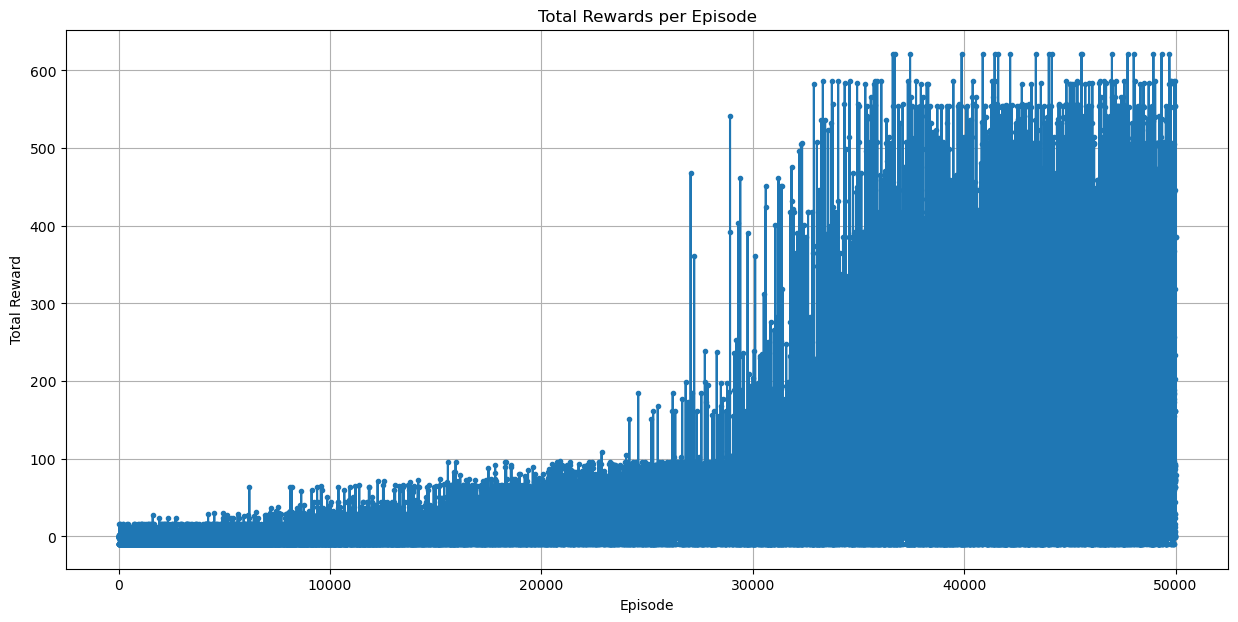

In [10]:
plt.figure(figsize=(15, 7))
plt.plot(agent.rewards_per_episode, marker='.')
plt.title("Total Rewards per Episode")
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.grid(True)
plt.show()

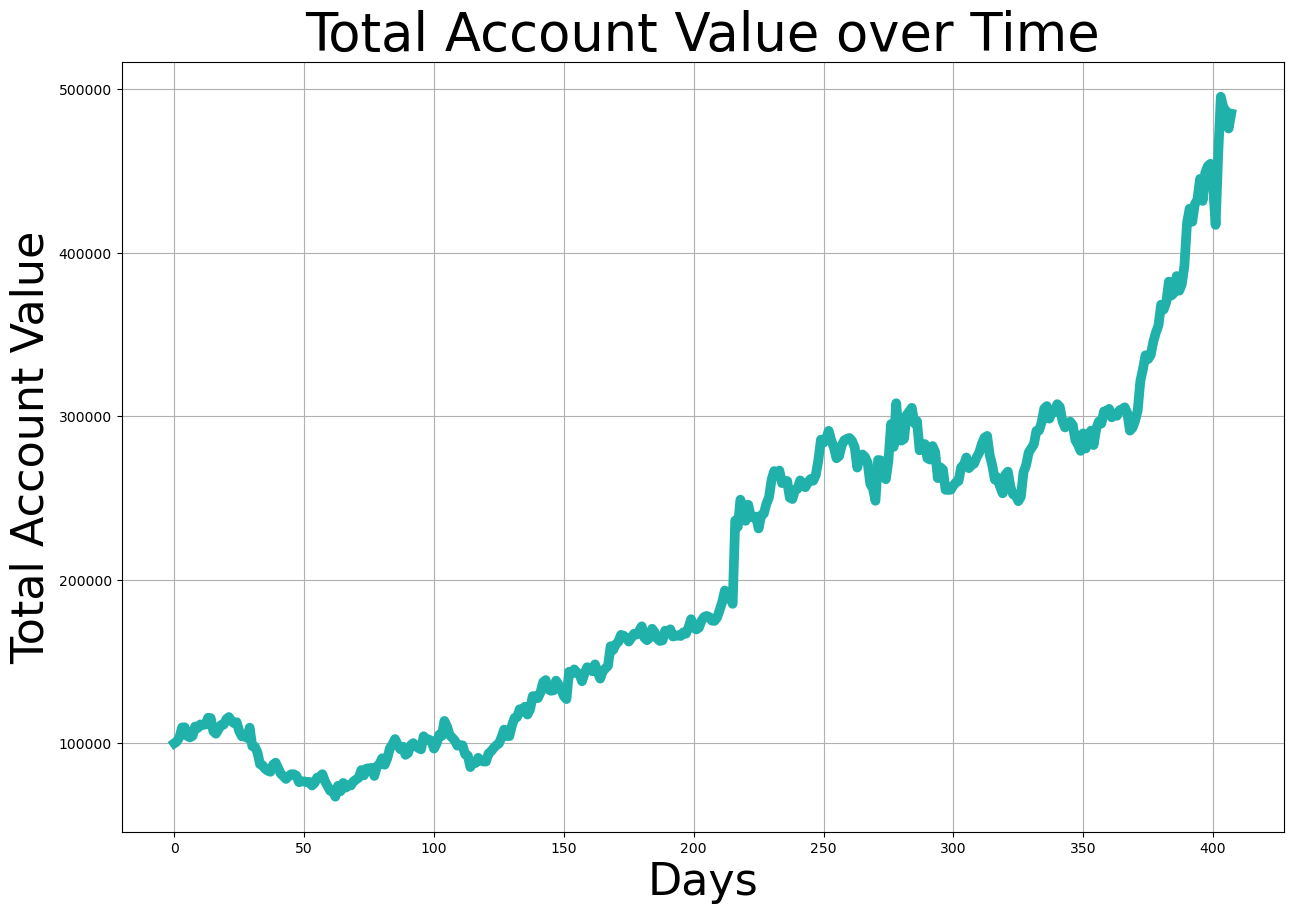

In [11]:
env_train.render()

In [12]:
print("Performing actions based on Q-table:-\n")

for episode in range(1):
    print("Episode:", episode+1)
    obs, info = env_test.reset()
    terminated, truncated = False, False

    step_dir = {0: "down", 1: "up", 2: "right", 3: "left", 4: "pick-up", 5: "drop-off"}
    time_step = 1

    while not terminated:
        action = Learned_Q_Action(obs, q_table)  # Select the best action
        obs, reward, terminated, truncated, info = env_test.step(action)
        print(f"Action: {action:<2} {str('(') + step_dir[action] + str(')'):<11} | Reward: {reward:<20} | Done: {str(terminated):<5} | Timestep: {time_step:<2}")
        time_step += 1

Performing actions based on Q-table:-

Episode: 1
Action: 0  (down)      | Reward: 1                    | Done: False | Timestep: 1 
Action: 2  (right)     | Reward: 3.977913263545378    | Done: False | Timestep: 2 
Action: 2  (right)     | Reward: -0.2645841481652087  | Done: False | Timestep: 3 
Action: 2  (right)     | Reward: 3.298052455999064    | Done: False | Timestep: 4 
Action: 2  (right)     | Reward: 6.177387553203715    | Done: False | Timestep: 5 
Action: 2  (right)     | Reward: 4.844126308524083    | Done: False | Timestep: 6 
Action: 2  (right)     | Reward: 8.065112159208544    | Done: False | Timestep: 7 
Action: 2  (right)     | Reward: 10.262277694696868   | Done: False | Timestep: 8 
Action: 2  (right)     | Reward: 7.111468998044376    | Done: False | Timestep: 9 
Action: 2  (right)     | Reward: 3.5315771310249473   | Done: False | Timestep: 10
Action: 2  (right)     | Reward: 3.8755366386747725   | Done: False | Timestep: 11
Action: 2  (right)     | Reward: 1.74

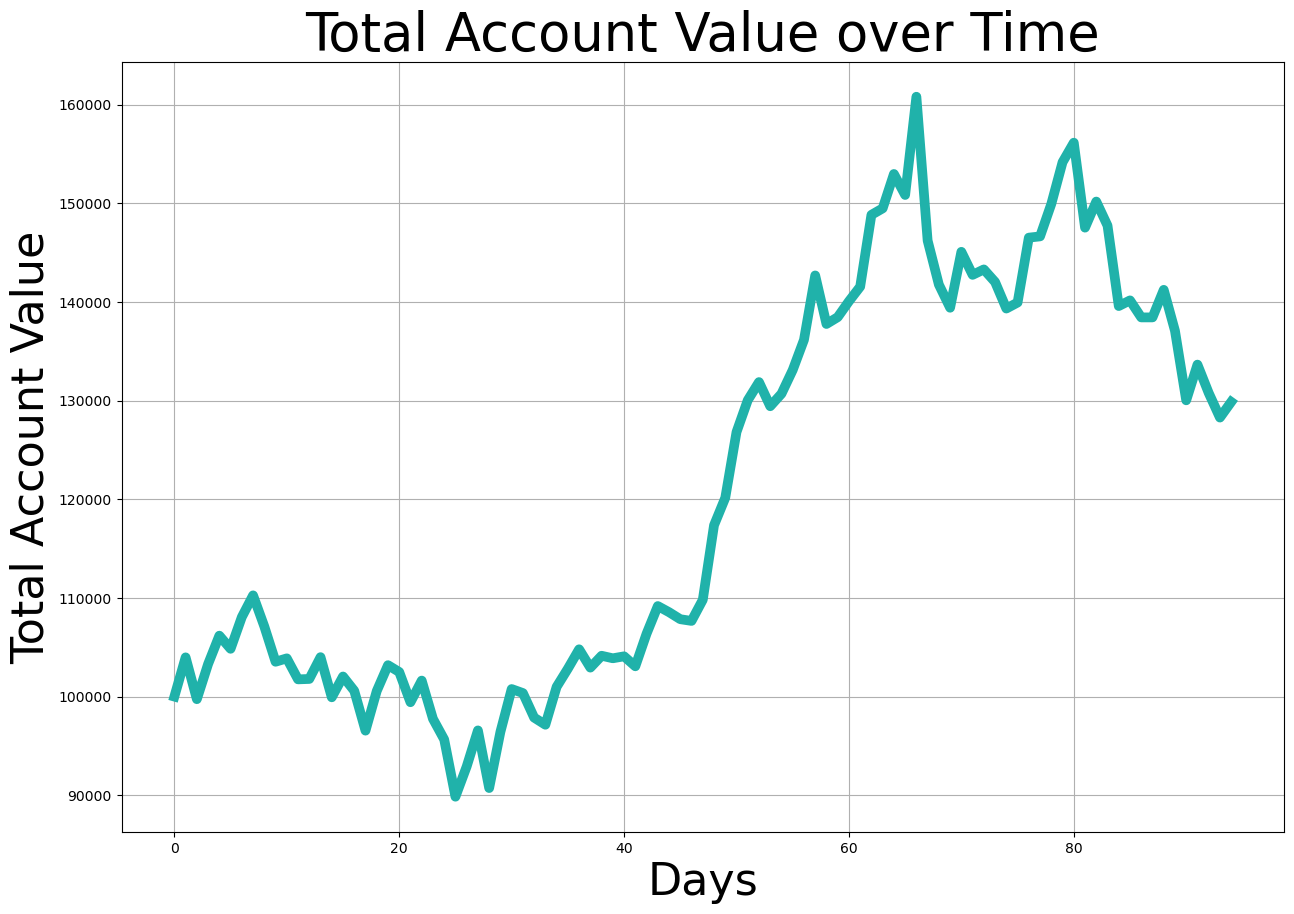

In [13]:
env_test.render()